In [2]:
!pip install -q --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git

from google.colab import drive
drive.mount("/content/drive")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from aeroguard.data import table_vols
from aeroguard.normalisation import calculer_residus, CAPTEURS
from aeroguard.features import ajouter_phase, features_par_vol

DOSSIER = "/content/drive/MyDrive/aeroguard"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dev = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_dev.parquet")
test = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_test.parquet")
modele = joblib.load(f"{DOSSIER}/models/modele_sain.joblib")
print(dev.shape, test.shape)

(4906636, 33) (2735232, 33)


In [4]:
def preparer(df):
    df = ajouter_phase(df)
    res = calculer_residus(df, modele)
    res["phase"] = df["phase"].values
    return df, res

dev, res_dev = preparer(dev)
test, res_test = preparer(test)
print(res_dev["phase"].value_counts(normalize=True).round(3))

phase
descente     0.387
croisiere    0.363
montee       0.250
Name: proportion, dtype: float64


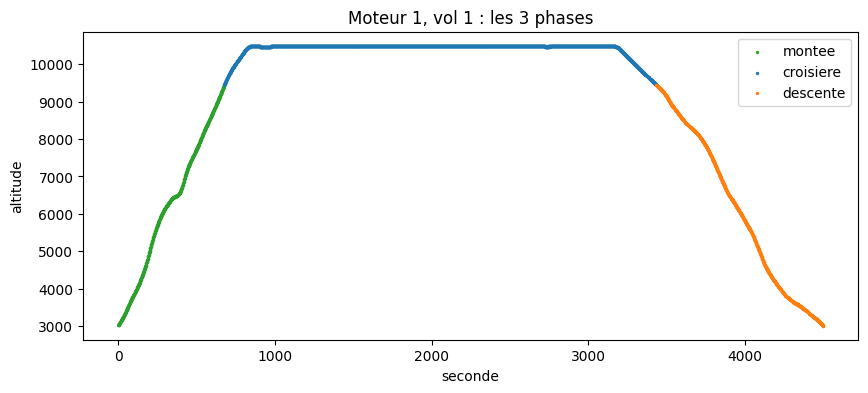

In [5]:
un_vol = dev[(dev["unit"] == 1) & (dev["cycle"] == 1)].reset_index(drop=True)
couleurs = {"montee": "tab:green", "croisiere": "tab:blue", "descente": "tab:orange"}

plt.figure(figsize=(10, 4))
for p, c in couleurs.items():
    partie = un_vol[un_vol["phase"] == p]
    plt.scatter(partie.index, partie["alt"], s=2, color=c, label=p)
plt.xlabel("seconde"); plt.ylabel("altitude"); plt.legend()
plt.title("Moteur 1, vol 1 : les 3 phases")
plt.show()

In [6]:
feat_dev = features_par_vol(res_dev, CAPTEURS)
feat_test = features_par_vol(res_test, CAPTEURS)
print("Forme :", feat_dev.shape)
print("Valeurs manquantes :", feat_dev.isna().sum().sum())
feat_dev.iloc[:3, :8]

Forme : (553, 128)
Valeurs manquantes : 0


,unit,cycle,T24_mean_montee,T24_mean_croisiere,T24_mean_descente,T24_std_montee,T24_std_croisiere,T24_std_descente
0,1,1,-0.030935,-0.086733,-0.026309,0.112441,0.105047,0.092328
1,1,2,-0.040325,-0.061966,-0.043735,0.159995,0.139986,0.133002
2,1,3,-0.026873,0.007359,0.052391,0.044093,0.139758,0.112423


In [7]:
def ajouter_etiquettes(feats, df):
    etiq = table_vols(df)
    fc = df.groupby(["unit", "cycle"])["Fc"].first().reset_index()
    return feats.merge(etiq, on=["unit", "cycle"]).merge(fc, on=["unit", "cycle"])

feat_dev = ajouter_etiquettes(feat_dev, dev)
feat_test = ajouter_etiquettes(feat_test, test)
print(feat_dev.shape)
feat_dev[["unit", "cycle", "hs", "RUL", "duree_s", "Fc"]].head()

(553, 132)


,unit,cycle,hs,RUL,duree_s,Fc
0,1,1,1,99,4498,1
1,1,2,1,98,4660,1
2,1,3,1,97,5355,1
3,1,4,1,96,4181,1
4,1,5,1,95,4495,1


In [8]:
colonnes = [c for c in feat_dev.columns if c.count("_") == 2]    # les 126 features
sains = feat_dev[feat_dev["cycle"] <= 15]
uses = feat_dev[feat_dev["RUL"] <= 10]                           # les 10 derniers vols

separation = (uses[colonnes].mean() - sains[colonnes].mean()) / sains[colonnes].std()
top = separation.sort_values(key=abs, ascending=False)
print(top.head(10).round(1))

T48_mean_montee       40.799999
T50_mean_montee       38.799999
Nc_mean_montee       -30.299999
T48_mean_croisiere    26.299999
T50_mean_croisiere    25.799999
T24_mean_montee       19.500000
T30_mean_montee      -18.700001
T50_mean_descente     18.400000
T48_mean_descente     16.500000
Nc_max_montee        -12.700000
dtype: float32


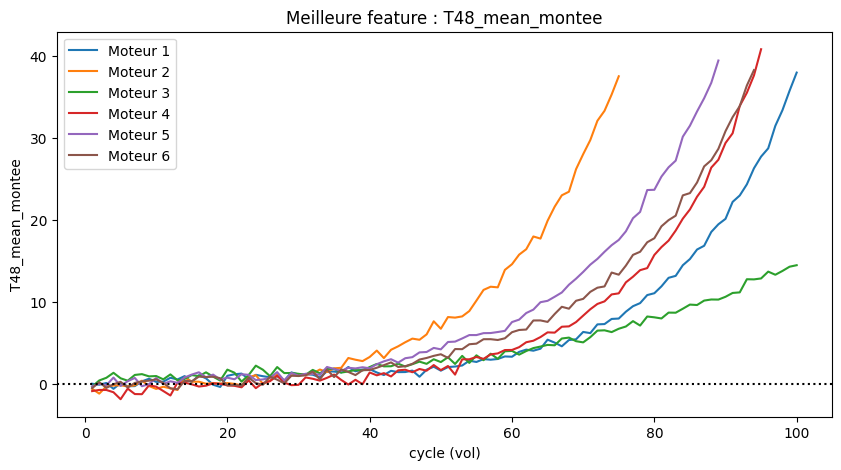

In [9]:
meilleure = top.index[0]
plt.figure(figsize=(10, 5))
for u, m in feat_dev.groupby("unit"):
    plt.plot(m["cycle"], m[meilleure], label=f"Moteur {u}")
plt.axhline(0, color="black", linestyle=":")
plt.xlabel("cycle (vol)"); plt.ylabel(meilleure)
plt.title(f"Meilleure feature : {meilleure}")
plt.legend()
plt.savefig(f"{DOSSIER}/results/figures/17_meilleure_feature.png", dpi=120)
plt.show()

In [10]:
feat_dev.to_parquet(f"{DOSSIER}/data/processed/ds01_dev_features.parquet")
feat_test.to_parquet(f"{DOSSIER}/data/processed/ds01_test_features.parquet")
print("Sauvegardé ✅", feat_dev.shape, feat_test.shape)

Sauvegardé ✅ (553, 132) (341, 132)
